# Assignment 2: Predictive modelling
**Github**: https://github.com/hucann/DSA4262

**Colab**: https://colab.research.google.com/drive/1EbBNmNqbA1KUMJiwOo9BE-zlknHTOCLr?usp=sharing


# 0. Set Up

This notebook is designed to run on Google Colab, as fine-tuning DistilBERT requires GPU acceleration.

Before running:

- Either upload the project files directly to Colab **or** mount Google Drive.
- Update all file paths (e.g., dataset location, model save directory) to match your Drive or working directory.
- Ensure GPU is enabled for **Section 2.3 DistillBERT**: `Runtime → Change runtime type → GPU`. Other sections do not require GPU.

In [1]:
# Install libraries that are not in Colab by default
!pip install datasets sentence-transformers lightgbm shap evaluate transformers>=4.46

In [2]:
# ===== Core Libraries =====
import os
import numpy as np
import pandas as pd
import torch
import joblib
from itertools import product

# ===== Visualization =====
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# ===== Scikit-learn =====
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    ParameterGrid,
    train_test_split
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    f1_score,
    confusion_matrix
)

# ===== NLP / Transformers =====
from datasets import Dataset
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)
from sentence_transformers import SentenceTransformer
from torch.nn.functional import softmax

# ===== Gradient Boosting =====
import lightgbm as lgb

# ===== Evaluation / Explainability =====
import evaluate
import shap

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df_train = pd.read_csv("/content/drive/MyDrive/Dreaddit/dreaddit-train.csv")
df_test = pd.read_csv("/content/drive/MyDrive/Dreaddit/dreaddit-test.csv")

df_train.head()

,subreddit,post_id,sentence_range,text,id,label,confidence,social_timestamp,social_karma,syntax_ari,...,lex_dal_min_pleasantness,lex_dal_min_activation,lex_dal_min_imagery,lex_dal_avg_activation,lex_dal_avg_imagery,lex_dal_avg_pleasantness,social_upvote_ratio,social_num_comments,syntax_fk_grade,sentiment
0,ptsd,8601tu,"(15, 20)","He said he had not felt that way before, sugge...",33181,1,0.8,1521614353,5,1.806818,...,1.000,1.1250,1.0,1.77000,1.52211,1.89556,0.86,1,3.253573,-0.002742
1,assistance,8lbrx9,"(0, 5)","Hey there r/assistance, Not sure if this is th...",2606,0,1.0,1527009817,4,9.429737,...,1.125,1.0000,1.0,1.69586,1.62045,1.88919,0.65,2,8.828316,0.292857
2,ptsd,9ch1zh,"(15, 20)",My mom then hit me with the newspaper and it s...,38816,1,0.8,1535935605,2,7.769821,...,1.000,1.1429,1.0,1.83088,1.58108,1.85828,0.67,0,7.841667,0.011894
3,relationships,7rorpp,"[5, 10]","until i met my new boyfriend, he is amazing, h...",239,1,0.6,1516429555,0,2.667798,...,1.000,1.1250,1.0,1.75356,1.52114,1.98848,0.50,5,4.104027,0.141671
4,survivorsofabuse,9p2gbc,"[0, 5]",October is Domestic Violence Awareness Month a...,1421,1,0.8,1539809005,24,7.554238,...,1.000,1.1250,1.0,1.77644,1.64872,1.81456,1.00,1,7.910952,-0.204167


In [5]:
BASE_DIR = "/content/drive/MyDrive/Dreaddit"
MODEL_DIR = os.path.join(BASE_DIR, "final_model")
PRED_DIR = os.path.join(BASE_DIR, "predictions")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(PRED_DIR, exist_ok=True)

# 1. Exploratory Data Analysis (EDA)

### 1.1 Class Distribution

Class counts:
 label
0    1350
1    1488
Name: count, dtype: int64

Class percentage:
 label
0    47.56871
1    52.43129
Name: proportion, dtype: float64


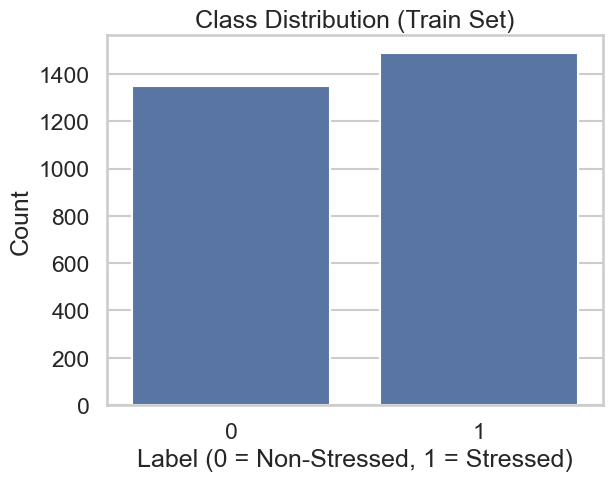

In [ ]:
sns.set(style="whitegrid", context="talk")

# Combine train + test for overall view (optional)
df_all = df_train.copy()

# Class distribution
class_counts = df_all["label"].value_counts().sort_index()
class_percent = df_all["label"].value_counts(normalize=True).sort_index() * 100

print("Class counts:\n", class_counts)
print("\nClass percentage:\n", class_percent)

# Plot
plt.figure()
sns.countplot(x="label", data=df_all)
plt.title("Class Distribution (Train Set)")
plt.xlabel("Label (0 = Non-Stressed, 1 = Stressed)")
plt.ylabel("Count")
plt.show()

The training set contains 2,838 posts:

- Non-stressed: 1,350 (47.6%)  
- Stressed: 1,488 (52.4%)

The dataset is approximately balanced, making F1-score an appropriate primary metric. Severe imbalance handling (e.g., aggressive reweighting) is unnecessary, but class-aware evaluation remains important given the clinical implications of false negatives and false positives.

### 1.2 Stress Rate by Subreddit

subreddit
anxiety             0.658052
domesticviolence    0.639241
almosthomeless      0.587500
ptsd                0.568493
stress              0.546875
survivorsofabuse    0.457143
relationships       0.447464
food_pantry         0.378378
homeless            0.375000
assistance          0.363322
Name: label, dtype: float64


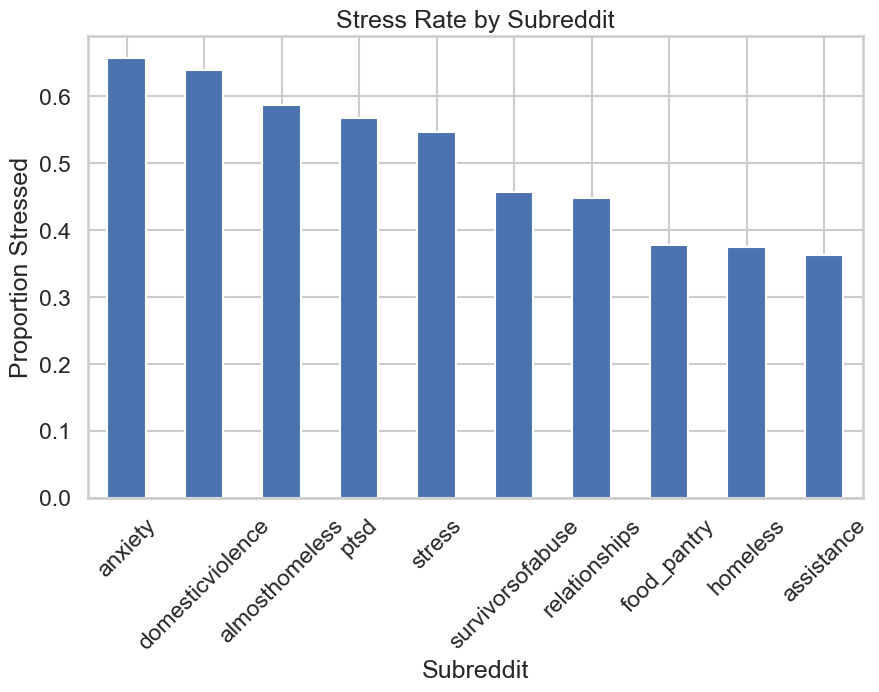

In [ ]:
# Stress Rate per Subreddit
stress_rate = (
    df_all
    .groupby("subreddit")["label"]
    .mean()
    .sort_values(ascending=False)
)

print(stress_rate)

plt.figure(figsize=(10,6))
stress_rate.plot(kind="bar")
plt.title("Stress Rate by Subreddit")
plt.ylabel("Proportion Stressed")
plt.xlabel("Subreddit")
plt.xticks(rotation=45)
plt.show()

Stress prevalence varies substantially across communities (0.36–0.66).

Mental health–focused communities (e.g., anxiety, ptsd) show the highest stress rates. In contrast, instrumental-support communities (e.g., assistance, homeless, relationships) show lower prevalence.

This variation suggests two important points:

1. **Community norms shape linguistic expression.**  
   In mental health spaces, distress is more explicitly labeled. In logistical or situational communities, stress may be embedded within practical discussions.

2. **Prediction difficulty is likely community-dependent.**  
   If stress is lexically explicit in some communities but narratively implicit in others, model performance may vary accordingly.

This motivates later subreddit-level performance analysis.

### 1.3 LIWC Analysis by Label

label                          0          1
lex_liwc_affect         5.579644   6.567137
lex_liwc_posemo         3.419896   2.042789
lex_liwc_negemo         2.074133   4.421203
lex_liwc_anx            0.513163   1.278038
lex_liwc_anger          0.595830   1.230383
lex_liwc_sad            0.373104   0.802903
lex_liwc_i              7.110022  10.841062
lex_liwc_we             0.997393   0.553548
lex_liwc_cogproc       13.048704  14.090558
lex_liwc_insight        2.626148   3.062836
lex_liwc_tentat         3.378178   3.276290
lex_liwc_certain        1.489756   1.593730
lex_liwc_focuspast      5.306444   4.833669
lex_liwc_focuspresent  11.218681  13.326862
lex_liwc_focusfuture    1.277104   1.098145


<Figure size 1000x800 with 0 Axes>

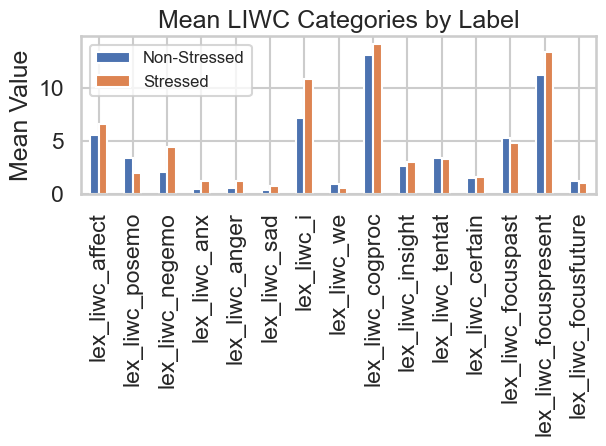

In [ ]:
# Focus on psychologically meaningful categories
liwc_cols = [
    "lex_liwc_affect",
    "lex_liwc_posemo",
    "lex_liwc_negemo",
    "lex_liwc_anx",
    "lex_liwc_anger",
    "lex_liwc_sad",
    "lex_liwc_i",
    "lex_liwc_we",
    "lex_liwc_cogproc",
    "lex_liwc_insight",
    "lex_liwc_tentat",
    "lex_liwc_certain",
    "lex_liwc_focuspast",
    "lex_liwc_focuspresent",
    "lex_liwc_focusfuture"
]

liwc_means = df_all.groupby("label")[liwc_cols].mean().T

print(liwc_means)

# Plot
plt.figure(figsize=(10,8))
liwc_means.plot(kind="bar")
plt.title("Mean LIWC Categories by Label")
plt.ylabel("Mean Value")
plt.xticks(rotation=90)
plt.legend(["Non-Stressed", "Stressed"], fontsize=12)
plt.tight_layout()
plt.show()

Stressed posts show:

- Higher negative emotion (negemo: 4.42 vs. 2.07)  
- Higher anxiety (1.28 vs. 0.51)  
- Higher anger (1.23 vs. 0.60)  
- Higher sadness (0.80 vs. 0.37)  
- Lower positive emotion (posemo: 2.04 vs. 3.42)

They also exhibit:

- Higher first-person singular pronoun use (“I”) (10.84 vs. 7.11)  
- Lower use of “we” (0.55 vs. 1.00)  
- Slightly higher cognitive processing words  
- Higher insight words  

Overall, the linguistic signals align with psychological literature: stress is associated with negative affect, self-focus, and cognitive processing.

In later sections, we examine whether trained models recover these psychologically meaningful patterns — or whether they rely on more superficial lexical cues.

# 2. Modelling
We compare three modelling paradigms:

| Model | Representation | Rationale |
|--------|---------------|------------|
| TF-IDF + Logistic Regression | Sparse lexical | Interpretable baseline |
| SBERT + LIWC + LightGBM | Semantic + psychological | Psychologically grounded hybrid |
| DistilBERT | Contextual transformer | Strong contextual understanding |

The goal is not only performance maximisation, but understanding how different representations operationalise stress.

## 2.1 Baseline Model: TF-IDF + Logistic Regression
A sparse lexical baseline provides transparency and interpretability. It captures surface word-level signals but lacks contextual understanding.

In [15]:
# Build Pipeline to fit TF-IDF inside CV folds -> prevents data leakage
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english")),
    ("clf", LogisticRegression(
        solver="liblinear",       # stable for small-medium text data
        class_weight="balanced",  # slightly imbalanced dataset
        max_iter=2000             # large value to ensure convergence
    ))
])

In [16]:
# Stratified 5-Fold CV with hyperparameter tuning
param_grid = {
    "tfidf__ngram_range": [(1,1), (1,2)],
    "tfidf__max_features": [5000, 10000, 20000],
    "clf__C": [0.01, 0.1, 1, 10]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    verbose=1,
    refit=True  # retrain best model on the entire training set after cv
)

grid_search.fit(df_train["text"], df_train["label"])

# Best parameters and CV score
print("Best parameters:")
print(grid_search.best_params_)

print("\nBest CV F1-score:")
print(grid_search.best_score_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters:
{'clf__C': 10, 'tfidf__max_features': 20000, 'tfidf__ngram_range': (1, 2)}

Best CV F1-score:
0.7566321945040893


In [17]:
# Evaluate on test set
baseline_model = grid_search.best_estimator_

test_preds = baseline_model.predict(df_test["text"])
baseline_test_f1 = f1_score(df_test["label"], test_preds)

print("Test F1-score for Baseline:", baseline_test_f1)
print("\nClassification Report:\n")
print(classification_report(df_test["label"], test_preds))

Test F1-score for Baseline: 0.7237354085603113

Classification Report:

              precision    recall  f1-score   support

           0       0.71      0.64      0.68       346
           1       0.69      0.76      0.72       369

    accuracy                           0.70       715
   macro avg       0.70      0.70      0.70       715
weighted avg       0.70      0.70      0.70       715



In [38]:
# Save model
joblib.dump(baseline_model, os.path.join(MODEL_DIR, "baseline_model.joblib"))

# Save predictions (with probability + confidence)
test_preds = baseline_model.predict(df_test["text"])
test_probs = baseline_model.predict_proba(df_test["text"])
prob_stress = test_probs[:, 1]
pred_confidence = test_probs[np.arange(len(test_probs)), test_preds] # Confidence = probability of predicted class

# Create results dataframe
df_test_results = df_test.copy()
df_test_results["predicted_label"] = test_preds
df_test_results["prob_stress"] = prob_stress
df_test_results["pred_confidence"] = pred_confidence

df_test_results.to_csv(os.path.join(PRED_DIR, "baseline_predictions.csv"),index=False)

---

## 2.2 Hybrid Model: SBERT + LIWC → LightGBM
This model combines semantic embeddings (SBERT) with psychologically grounded LIWC features. It integrates contextual meaning with theory-driven constructs.


In [14]:
# Generate SBERT Embeddings for text
model_name = "all-MiniLM-L6-v2"
sbert_model = SentenceTransformer(model_name)

X_train_embed = sbert_model.encode(
    df_train["text"].tolist(),
    batch_size=32,
    show_progress_bar=True
)

X_test_embed = sbert_model.encode(
    df_test["text"].tolist(),
    batch_size=32,
    show_progress_bar=True
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/89 [00:00<?, ?it/s]

Batches:   0%|          | 0/23 [00:00<?, ?it/s]

In [15]:
# Combine SBERT Features and LIWC features

embedding_dim = 384  # Dim for all-MiniLM-L6-v2
liwc_cols = [col for col in df_train.columns if col.startswith("lex_liwc_")]
all_feature_names = [f"sbert_{i}" for i in range(embedding_dim)] + liwc_cols

X_train = np.hstack([X_train_embed, df_train[liwc_cols].values])
X_test = np.hstack([X_test_embed, df_test[liwc_cols].values])
y_train = df_train["label"].values
y_test = df_test["label"].values

In [30]:
# Stratified 5-Fold CV with hyperparameter tuning

param_grid = {
    "learning_rate": [0.05],        # Faster convergence than 0.01
    "n_estimators": [1000],         # Early stopping handles the actual count
    "num_leaves": [31, 63],         # Main complexity control
    "reg_alpha": [0.1, 0.5],        # Essential regularization
    "colsample_bytree": [0.8, 1.0] # Feature diversity
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_score = 0
best_params = None
grid_list = list(ParameterGrid(param_grid))


import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names")
print(f"Starting Grid Search: {len(grid_list)} combinations...")

for params in tqdm(grid_list, desc="Hyperparameter Tuning"):
    fold_scores = []

    for train_idx, val_idx in skf.split(X_train, y_train):
        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        model = lgb.LGBMClassifier(
            objective="binary",
            class_weight="balanced",
            random_state=42,
            verbosity=-1,
            **params
        )

        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            feature_name=all_feature_names,
            eval_metric="binary_logloss",
            callbacks=[lgb.early_stopping(20, verbose=False)]
        )

        val_preds = model.predict(X_val)
        fold_scores.append(f1_score(y_val, val_preds))

    mean_f1 = np.mean(fold_scores)
    if mean_f1 > best_score:
        best_score = mean_f1
        best_params = params

print(f"\nBest CV F1: {best_score:.4f}")
print("Best Params:", best_params)

Starting Grid Search: 8 combinations...


Hyperparameter Tuning: 100%|██████████| 8/8 [08:58<00:00, 67.31s/it]


Best CV F1: 0.7882
Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'n_estimators': 1000, 'num_leaves': 31, 'reg_alpha': 0.5}


In [31]:
# Train final model on full training set
hybrid_model = lgb.LGBMClassifier(
    objective="binary",
    class_weight="balanced",
    random_state=42,
    verbosity=-1,
    **best_params
)

hybrid_model.fit(X_train, y_train, feature_name=all_feature_names)

LGBMClassifier(class_weight='balanced', colsample_bytree=0.8,
               learning_rate=0.05, n_estimators=1000, objective='binary',
               random_state=42, reg_alpha=0.5, verbosity=-1)

In [32]:
# Evaluate on test set
hybrid_test_preds = hybrid_model.predict(X_test)
hybrid_test_f1 = f1_score(y_test, hybrid_test_preds)

print("Hybrid Model Test F1:", hybrid_test_f1)
print("\nClassification Report:\n")
print(classification_report(y_test, hybrid_test_preds))

Hybrid Model Test F1: 0.7786666666666666

Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.74      0.76       346
           1       0.77      0.79      0.78       369

    accuracy                           0.77       715
   macro avg       0.77      0.77      0.77       715
weighted avg       0.77      0.77      0.77       715



In [39]:
# Save model
joblib.dump(hybrid_model, os.path.join(MODEL_DIR, "hybrid_model.joblib"))

# Save predictions (with probability + confidence)
test_preds = hybrid_model.predict(X_test)
test_probs = hybrid_model.predict_proba(X_test)
prob_stress = test_probs[:, 1]
pred_confidence = test_probs[np.arange(len(test_probs)), test_preds] # Confidence = probability of predicted class

# Create results dataframe
df_test_results = df_test.copy()
df_test_results["predicted_label"] = test_preds
df_test_results["prob_stress"] = prob_stress
df_test_results["pred_confidence"] = pred_confidence

df_test_results.to_csv(os.path.join(PRED_DIR, "hybrid_predictions.csv"),index=False)

---

## 2.3 Deep Model: DistillBERT
DistilBERT directly fine-tunes a contextual transformer on the classification task, allowing nuanced contextual modeling without manual feature engineering.


In [7]:
# Change to GPU runtime
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [8]:
# Create validation split from training set
df_train, df_val = train_test_split(
    df_train,
    test_size=0.1,
    stratify=df_train["label"],
    random_state=42
)

print("Train size:", len(df_train))
print("Validation size:", len(df_val))
print("Test size:", len(df_test))


Train size: 2554
Validation size: 284
Test size: 715


In [9]:
# Convert to Hugging Face Datasets
train_dataset = Dataset.from_pandas(df_train)
val_dataset = Dataset.from_pandas(df_val)
test_dataset = Dataset.from_pandas(df_test)

In [10]:
# Tokenization
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=256
    )

train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset = val_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

train_dataset = train_dataset.rename_column("label", "labels")
val_dataset = val_dataset.rename_column("label", "labels")
test_dataset = test_dataset.rename_column("label", "labels")

train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
val_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/2554 [00:00<?, ? examples/s]

Map:   0%|          | 0/284 [00:00<?, ? examples/s]

Map:   0%|          | 0/715 [00:00<?, ? examples/s]

In [11]:
# Metrics
metric_f1 = evaluate.load("f1")
metric_accuracy = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": metric_accuracy.compute(predictions=preds, references=labels)["accuracy"],
        "f1": metric_f1.compute(predictions=preds, references=labels)["f1"]
    }

In [12]:
param_grid = {
    "learning_rate": [2e-5, 3e-5, 5e-5],
    "per_device_train_batch_size": [8, 16],
    "weight_decay": [0.0, 0.01]
}

In [18]:
# Hyperparameter tuning with early stopping
best_f1 = 0
best_params = None

for lr, batch_size, wd in product(
    param_grid["learning_rate"],
    param_grid["per_device_train_batch_size"],
    param_grid["weight_decay"]
):

    print(f"\nTraining with lr={lr}, batch={batch_size}, wd={wd}")

    model = DistilBertForSequenceClassification.from_pretrained(
        "distilbert-base-uncased",
        num_labels=2
    ).to(device)

    training_args = TrainingArguments(
      output_dir="./temp",
      evaluation_strategy="epoch",
      save_strategy="epoch",
      save_total_limit=1,
      learning_rate=lr,
      per_device_train_batch_size=batch_size,
      per_device_eval_batch_size=batch_size,
      num_train_epochs=5,
      weight_decay=wd,
      load_best_model_at_end=True,
      metric_for_best_model="f1",
      greater_is_better=True,
      fp16=True,
      report_to="none",
      seed=42
  )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )

    trainer.train()

    val_results = trainer.evaluate()
    val_f1 = val_results["eval_f1"]

    print("Validation F1:", val_f1)

    if val_f1 > best_f1:
        best_f1 = val_f1
        best_params = {
            "learning_rate": lr,
            "batch_size": batch_size,
            "weight_decay": wd
        }

print("\nBest Parameters:", best_params)
print("Best Validation F1:", best_f1)


Training with lr=2e-05, batch=8, wd=0.0


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.472634,0.785211,0.806349
2,0.444020,0.567416,0.795775,0.818750
3,0.444020,0.806679,0.799296,0.813115
4,0.222923,0.971022,0.788732,0.798658


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Validation F1: 0.8113207547169812

Best Parameters: {'learning_rate': 2e-05, 'batch_size': 16, 'weight_decay': 0.0}
Best Validation F1: 0.8278145695364238


Classical models were evaluated with 5-fold cross-validation due to higher variance and absence of pretraining. Transformer-based models were evaluated using a train/validation/test split following standard NLP fine-tuning practice.

In [13]:
# Retrain on full training set with best hyperparameters
combined_df = pd.concat([df_train, df_val])
combined_dataset = Dataset.from_pandas(combined_df)

combined_dataset = combined_dataset.map(tokenize, batched=True)
combined_dataset = combined_dataset.rename_column("label", "labels")
combined_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

final_model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
).to(device)

final_training_args = TrainingArguments(
    output_dir=MODEL_DIR,
    eval_strategy="no",
    save_strategy="no",
    learning_rate=best_params["learning_rate"],
    per_device_train_batch_size=best_params["batch_size"],
    per_device_eval_batch_size=best_params["batch_size"],
    num_train_epochs=5,
    weight_decay=best_params["weight_decay"],
    fp16=True,
    report_to="none",
    seed=42
)

final_trainer = Trainer(
    model=final_model,
    args=final_training_args,
    train_dataset=combined_dataset,
    processing_class=tokenizer
)

final_trainer.train()

Map:   0%|          | 0/2838 [00:00<?, ? examples/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
500,0.354296


TrainOutput(global_step=890, training_loss=0.25216787959752457, metrics={'train_runtime': 96.5737, 'train_samples_per_second': 146.934, 'train_steps_per_second': 9.216, 'total_flos': 939856193464320.0, 'train_loss': 0.25216787959752457, 'epoch': 5.0})

In [22]:
final_trainer.save_model(MODEL_DIR)
tokenizer.save_pretrained(MODEL_DIR)
print("Final model saved.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Final model saved.


In [17]:
test_results = final_trainer.evaluate(test_dataset)
print("Final Test Results:", test_results)

predictions = final_trainer.predict(test_dataset)
deep_test_preds = np.argmax(predictions.predictions, axis=1)
deep_test_f1 = f1_score(df_test["label"], deep_test_preds)

print("Deep Model Test F1:", deep_test_f1)
print(classification_report(df_test["label"], deep_test_preds))

Final Test Results: {'eval_loss': 0.7674693465232849, 'eval_runtime': 1.5309, 'eval_samples_per_second': 467.057, 'eval_steps_per_second': 29.395, 'epoch': 5.0}
Deep Model Test F1: 0.8214285714285714
              precision    recall  f1-score   support

           0       0.84      0.73      0.78       346
           1       0.78      0.87      0.82       369

    accuracy                           0.80       715
   macro avg       0.81      0.80      0.80       715
weighted avg       0.81      0.80      0.80       715



In [18]:
logits = predictions.predictions
probs = softmax(torch.tensor(logits), dim=1).numpy()
confidence = np.max(probs, axis=1)
prob_stress = probs[:, 1]

# Save predictions and probabilities
df_test_results = df_test.copy()
df_test_results["predicted_label"] = deep_test_preds
df_test_results["prob_stress"] = prob_stress
df_test_results["pred_confidence"] = confidence

df_test_results.to_csv(os.path.join(PRED_DIR, "deep_predictions.csv"), index=False)

---

## Model Comparison

| Model | F1 | Precision | Recall |
| :--- | :--- | :--- | :--- |
| **TF-IDF + LR** | 0.70 | 0.70 | 0.70 |
| **SBERT + LIWC** | 0.77 | 0.77 | 0.77 |
| **DistilBERT** | 0.80 | 0.81 | 0.80 |

DistilBERT achieves the highest F1-score and is selected as the final predictive model.

Nevertheless, simpler models are retained for interpretability and theoretical analysis.

# 3. Analysis

In [21]:
# Load prediction of DistillBERT
PRED_PATH = os.path.join(PRED_DIR, "deep_predictions.csv")
df_pred = pd.read_csv(PRED_PATH)

## 3.1 Subreddit Performance Analysis
To examine whether stress detection performance varies across community contexts, we computed F1-scores separately for each subreddit in the Dreaddit test set.

In [23]:
# Compute F1 per subreddit
subreddit_scores = []

for sub in df_pred["subreddit"].unique():
    subset = df_pred[df_pred["subreddit"] == sub]

    if len(subset) > 5:  # avoid tiny sample instability
        f1 = f1_score(subset["label"], subset["predicted_label"])

        subreddit_scores.append({
            "subreddit": sub,
            "size": len(subset),
            "f1": f1
        })

subreddit_df = pd.DataFrame(subreddit_scores).sort_values("f1")
subreddit_df

,subreddit,size,f1
4,homeless,52,0.727273
0,relationships,142,0.728682
7,survivorsofabuse,70,0.782609
6,domesticviolence,72,0.824742
3,assistance,66,0.829268
8,stress,14,0.842105
9,food_pantry,6,0.857143
2,ptsd,127,0.858824
1,anxiety,147,0.869565
5,almosthomeless,19,0.916667


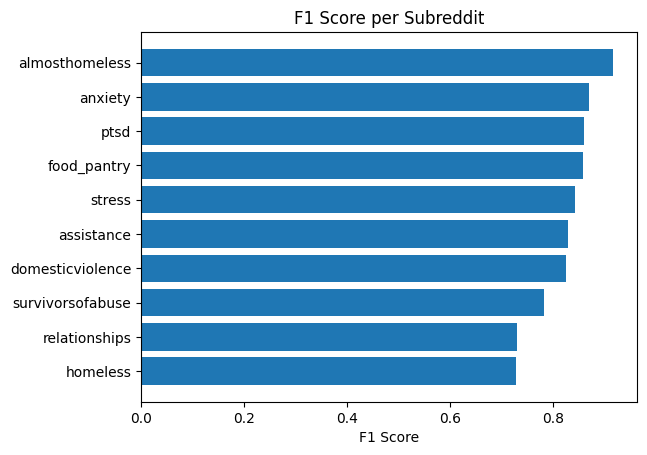

In [24]:
plt.figure()
plt.barh(subreddit_df["subreddit"], subreddit_df["f1"])
plt.xlabel("F1 Score")
plt.title("F1 Score per Subreddit")
plt.show()

Performance varies substantially across communities (0.73–0.92), indicating that model effectiveness is not uniform across social contexts.


### 1. Communities with Explicit Emotional Framing Are Easier to Classify

Subreddits such as r/anxiety, r/ptsd, and r/almosthomeless show the highest F1-scores.

These communities:

- Explicitly center on distress  
- Use direct emotional vocabulary  
- Frame experiences in psychological terms  

Stress signals are lexically salient and easier to detect.


### 2. Narrative-Based Communities Are Harder

Lower F1-scores appear in r/relationships and r/homeless.

Posts often:

- Embed distress within storytelling  
- Focus on interpersonal or logistical situations  
- Avoid explicit emotional labeling  

Here, stress is implied rather than declared.


### 3. Summary

| Community Type | Linguistic Pattern | Model Difficulty |
|----------------|-------------------|------------------|
| Mental health–focused | Direct affect expression | Easier |
| Situational / life-event | Indirect narrative expression | Harder |

The model performs best when distress is explicit and self-referential, and struggles when stress is context-dependent and embedded in broader narratives.

---

## 3.2 Error Analysis
To better understand the model’s limitations, we examine high-confidence errors (> 0.995 probability) to identify systematic blind spots.

In [29]:
# Filter incorrect prediction
errors = df_pred[df_pred["label"] != df_pred["predicted_label"]]

# Select 10 most confident wrong predictions
confident_errors = errors.sort_values("pred_confidence", ascending=False).head(10)

for idx, row in confident_errors.iterrows():
    print("="*80)
    print("INDEX:", idx)
    print("TRUE LABEL:", row["label"])
    print("PREDICTED:", row["predicted_label"])
    print("CONFIDENCE:", round(row["pred_confidence"], 4))
    print("SUBREDDIT:", row["subreddit"])
    print("ID:", row["id"])
    print("TEXT:", row["text"], "\n")

TRUE LABEL: 1
PREDICTED: 0
CONFIDENCE: 0.996
SUBREDDIT: relationships
ID: 18787
TEXT: Maybe anyone with a history of abuse or trauma can tell me if there are particular things to be sensitive to here: I tried to be supportive but obviously failed in the end here. She's talking about wanting to divorce me. We're looking into couples therapy. I really appreciate any insight or advice. **TLDR**: Wife is working on an art piece that is important for her career in the arts non-profit world. 

TRUE LABEL: 0
PREDICTED: 1
CONFIDENCE: 0.9958
SUBREDDIT: survivorsofabuse
ID: 439
TEXT: I sent a respectful email to my primary psychiatrist explaining my thoughts on how it was inappropriate to have Paterno's picture prominently displayed. Am I fucked up in the head for thinking this wrong? In the past, I had a mild traumatic brain injury. Sometimes I over react. 24 hours post appointment, I'm still bitter about the Paterno pics. 

TRUE LABEL: 0
PREDICTED: 1
CONFIDENCE: 0.9957
SUBREDDIT: ptsd
ID: 160


#### SHAP analysis (with DistillBERT)

In [6]:
# Load model
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_DIR)

deep_loaded = DistilBertForSequenceClassification.from_pretrained(MODEL_DIR)
deep_loaded.eval()

In [9]:
# Create shap explainer
def predict(texts):
    if isinstance(texts, np.ndarray):
        texts = texts.tolist()

    texts = [str(t) for t in texts]

    inputs = tokenizer(
        texts,
        padding=True,
        truncation=True,
        return_tensors="pt"
    )

    with torch.no_grad():
        outputs = deep_loaded(**inputs)

    probs = torch.softmax(outputs.logits, dim=1)
    return probs.cpu().numpy()

masker = shap.maskers.Text(tokenizer)
explainer = shap.Explainer(predict, masker)

False Positives

In [11]:
text = "I sent a respectful email to my primary psychiatrist explaining my thoughts on how it was inappropriate to have Paterno's picture prominently displayed. Am I fucked up in the head for thinking this wrong? In the past, I had a mild traumatic brain injury. Sometimes I over react. 24 hours post appointment, I'm still bitter about the Paterno pics. "
shap_values = explainer([text])
shap.plots.text(shap_values[0])

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [01:20, 80.68s/it]               


In [12]:
text = "Well, 18 years of being in and out of hospitals, treatment and addiction finally caught up to me. This is my first time homeless and it's scary but I'm grateful for the bright light that I've started to see. I don't abuse alcohol or drugs, but I'm no different than someone who does...I have other mental health issues that I feel nobody really can understand. It has essentially rendered me a useless piece of shit. I was engaging in unhealthy behaviors up to 10 hours a day, if not more. "
shap_values = explainer([text])
shap.plots.text(shap_values[0])

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [02:15, 135.47s/it]              


In [13]:
text = " I feel like I am just being written off because of my diagnosis before anyone even tries to look into it and see if anything else might be at play. I'd just as soon not say anything about my PTSD to be taken seriously, but it appears in my medical records. Or when I list my medications as required, Drs usually ask me what the meds are treating and it comes up then. Has anyone else had this experience? What has worked for you to be taken seriously? "
shap_values = explainer([text])
shap.plots.text(shap_values[0])

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [01:59, 119.23s/it]              


False Negatives

In [14]:
text = "Maybe anyone with a history of abuse or trauma can tell me if there are particular things to be sensitive to here: I tried to be supportive but obviously failed in the end here. She's talking about wanting to divorce me. We're looking into couples therapy. I really appreciate any insight or advice. **TLDR**: Wife is working on an art piece that is important for her career in the arts non-profit world. "
shap_values = explainer([text])
shap.plots.text(shap_values[0])

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [01:46, 106.43s/it]              


In [15]:
text = "I'd like to note that I have had a couple close individuals look at my emails, evidence, etc since the last court date. I'm not that crazy, but I showed them the emails because I wanted to make sure they were real. The emails, evidence, and notes are all real. I checked my phone history, and the phone calls to the advocate and office are all logged and sufficient in length to indicate that an actual conversation occurred. I never doubted reality before the abuse, and I have never done so outside of the abuse. "
shap_values = explainer([text])
shap.plots.text(shap_values[0])

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [02:21, 141.66s/it]              


### Pattern 1: Narrative Stress Without Emotional Labels (False Negatives)

Misclassified stressed posts often:

- Describe severe life events (divorce, illness, abuse, financial strain)  
- Contain long narrative structures  
- Lack explicit phrases like “I am anxious”  

SHAP shows diffuse contributions — no dominant emotional tokens drive predictions.

The model under-detects stress when it is situational rather than lexically explicit.


### Pattern 2: Psychological Vocabulary Without Acute Distress (False Positives)

Misclassified non-stressed posts include:

- Trauma-related terminology  
- Recovery narratives  
- Reflective discussion of diagnoses  

High-impact tokens include:

- “traumatic brain”
- “injury”
- “useless”
- “feel”
- “I”

The model is sensitive to disease-related vocabulary and negative lexical salience, even when posts are reflective rather than distressed.


### Pattern 3: Over-Reliance on Self-Referential Language

Across false positives, first-person pronouns (“I”, “me”, “feel”) receive strong importance.

While self-focus correlates with distress, it is also common in:

- Advice-seeking  
- Recovery narratives  
- Self-reflection  

The model appears to detect **self-referential intensity**, not necessarily stress.


### Summary

| Error Type | Linguistic Pattern | Model Bias |
|------------|-------------------|------------|
| False Negative | Event-heavy narrative, low explicit emotion | Under-detection of implicit stress |
| False Positive | Trauma vocabulary without acute distress | Over-detection of psychological terms |
| False Positive | High first-person usage | Confusing self-focus with stress |

DistilBERT primarily detects emotional intensity and lexical salience. It is less reliable at distinguishing:

- Active stress vs reflective discussion  
- Crisis vs recovery  
- Situational hardship vs psychological overwhelm

---

## 3.3 Stress Language Pattern

We examine global SHAP summary plots for:

1. TF-IDF + Logistic Regression  
2. SBERT + LIWC (LIWC features only)

### 1. TF-IDF: Surface Lexical Signals

In [10]:
# Load trained baseline model
baseline_loaded = joblib.load(os.path.join(MODEL_DIR, "baseline_model.joblib"))

tfidf = baseline_loaded.named_steps["tfidf"]
clf = baseline_loaded.named_steps["clf"]
feature_names = tfidf.get_feature_names_out()

X_train_tfidf = tfidf.transform(df_train["text"])
X_test_tfidf = tfidf.transform(df_test["text"])

# Create SHAP explainer
explainer = shap.LinearExplainer(clf, X_train_tfidf, feature_perturbation="interventional")

/usr/local/lib/python3.12/dist-packages/shap/explainers/_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


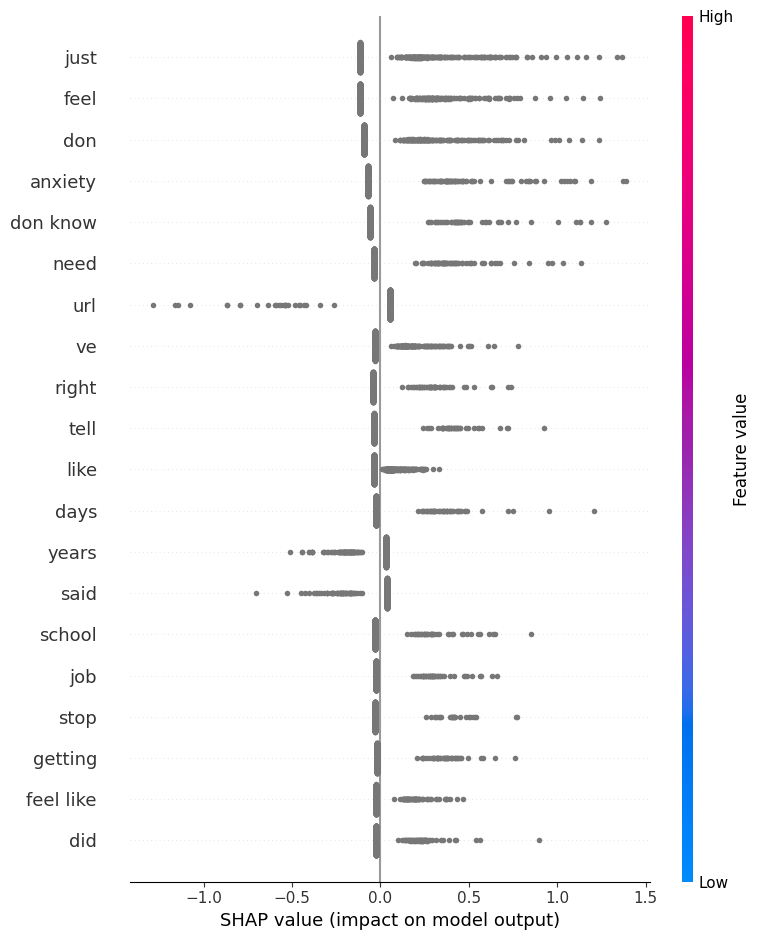

In [11]:
# SHAP global feature importance
X_sample = X_test_tfidf
shap_values = explainer.shap_values(X_sample)

shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=feature_names
)

The token *anxiety* is among the strongest predictors, confirming reliance on explicit diagnostic vocabulary.

Other stress-predictive tokens include:

- *feel*
- *don’t know*
- *need*

The baseline model associates stress with:

- Emotional self-report  
- Uncertainty  
- Unmet needs  

Tokens such as *school* and *job* suggest topic-stress correlations, indicating that institutional domains frequently co-occur with stress expression.

This model captures surface signals but lacks theoretical grounding.


### 2. SBERT + LIWC: Psychological Constructs

In [18]:
# Load trained hybrid model
hybrid_loaded = joblib.load(os.path.join(MODEL_DIR, "hybrid_model.joblib"))
## Ensure variables are in runtime: X_test (X_test_embed, X_test_liwc), embedding_dim, all_feature_names

# Initialize SHAP explainer
explainer = shap.TreeExplainer(hybrid_loaded)

X_sample = X_test
shap_values = explainer.shap_values(X_sample)

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


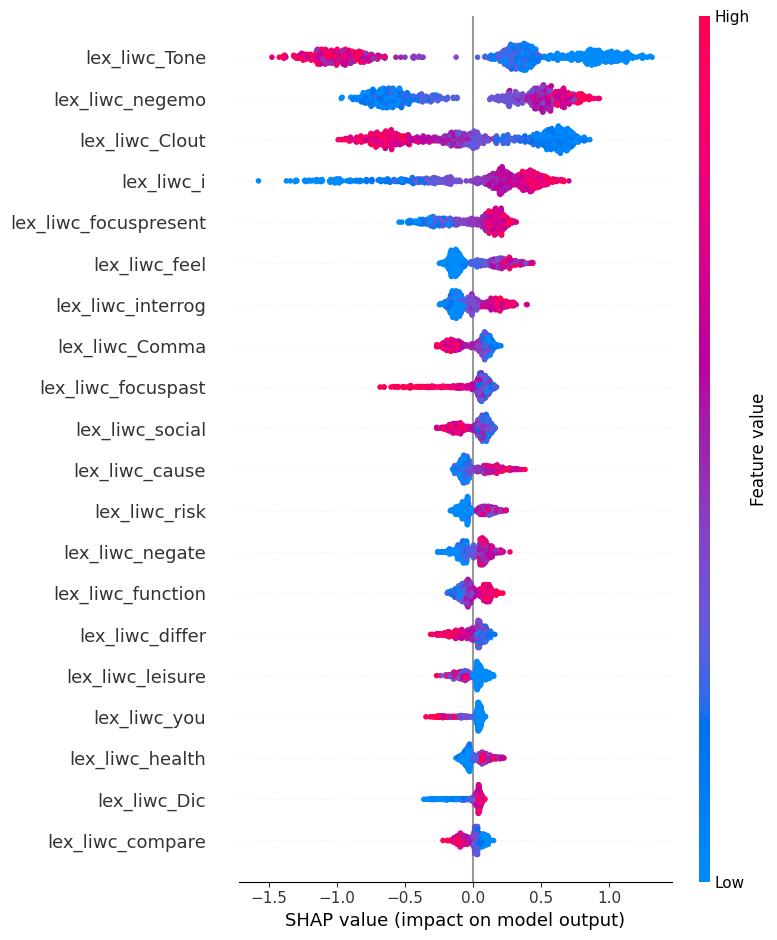

In [19]:
# Identify LIWC feature indices
liwc_start = embedding_dim
liwc_indices = list(range(liwc_start, len(all_feature_names)))

shap_values_liwc = shap_values[:, liwc_indices]
X_sample_liwc = X_sample[:, liwc_indices]

liwc_feature_names = all_feature_names[liwc_start:]

# LIWC only SHAP plot
shap.summary_plot(
    shap_values_liwc,
    X_sample_liwc,
    feature_names=liwc_feature_names
)

Key drivers include:

- Negative emotion  
- Low emotional tone  
- First-person singular pronouns  
- Low clout  

This aligns strongly with psychological theory:

Stress language profile:

- High self-focus  
- Negative affect  
- Reduced social confidence  
- Cognitive uncertainty  

### 3. Comparative Insight

| Dimension | TF-IDF | LIWC Hybrid |
|------------|---------|--------------|
| Signal Level | Word-level | Construct-level |
| Interpretability | Moderate | High |
| Theoretical Grounding | Limited | Strong |

The lexical model detects surface correlates.  
The LIWC model captures psychologically meaningful constructs.

Together, they confirm that stress language reflects a coherent psychological pattern — but contextual nuance remains challenging.

# 4. Clinical Ethics

### 4.1 False Negatives Risk

Missed stress may occur in:

- Narrative-heavy posts where distress is implied but not explicitly labeled  
- Stoic communicators who minimize or mask emotional language  
- Situational distress described factually without strong affective words  

Risk:  
Individuals experiencing genuine psychological distress may not be flagged. This limits opportunities for early detection, timely support, and preventive intervention, particularly for those who are less expressive.

---

### 4.2 False Positives Risk

Over-flagging may occur in:

- Recovery narratives describing past stress rather than current distress  
- Reflective trauma discussions intended for sharing or meaning-making  
- Diagnostic or informational conversations about mental health  

Risks include:

- Normalizing automated surveillance of emotional expression  
- Stigmatization or mislabeling of users as currently distressed  
- Misallocation of limited moderation or support resources toward low-risk cases  
- Erosion of user trust if benign content is repeatedly flagged

---

### 4.3 Automated Surveillance Risk

When deployed at scale, a stress detection model enables continuous monitoring of user-generated content. Even if intended for support or triage, it effectively performs invisible psychological profiling.

**Proactive scanning of all content**  
Unlike reactive moderation, automated systems can screen every post in real time. This raises concerns about informed consent, proportionality, and whether users are aware that their emotional expressions are being algorithmically evaluated.

**Chilling effects on expression**  
If users believe their emotional language is being constantly assessed, they may self-censor or avoid disclosing vulnerability. A tool designed to support mental health could unintentionally suppress open and honest expression.

**Function creep**  
A model developed for moderation triage could later be repurposed for other uses, such as targeted advertising, insurance or employment screening, or even government monitoring. The existence of stress scores creates secondary-use risks beyond the original intent.

For mental health applications, maintaining trust and clear boundaries is essential. Stress detection systems should augment human support, not normalize silent surveillance.


---

### 4.4 Stakeholder Perspectives and Safeguards

Deploying stress detection systems requires balancing performance with ethical responsibility.

**Forum Moderator**  
Moderators face a trade-off between recall and precision. High recall identifies more distressed posts, but too many false positives increase workload.  
Safeguard: The model should act as a decision-support tool, with mandatory human-in-the-loop review before any action is taken.

**Policy Maker**  
Concerned with population-level monitoring and potential community bias. The model may over-represent certain groups as distressed.  
Safeguard: Use the system only for clearly defined purposes (e.g., trend monitoring), conduct regular bias audits, and avoid permanent individual risk profiling.

**User**  
Concerned about privacy, consent, and invisible psychological profiling.  
Safeguard: Ensure transparency and clear user disclosure, limit secondary use of predictions, and prevent long-term personal risk scoring.

Across stakeholders, transparency, purpose limitation, and human oversight are essential to prevent automated surveillance from undermining trust.

# 5. Conclusion

This study examined stress detection across Reddit communities using lexical, hybrid, and transformer-based models. While DistilBERT achieved the strongest overall performance (F1 = 0.80), performance varied substantially across subreddits, highlighting that stress expression is community-dependent. Models performed best in mental health–focused spaces where distress is explicit, and struggled in narrative or situational communities where stress is implicit.

Linguistic analysis confirmed that stress language is characterized by negative affect, self-focus, and cognitive processing. However, error analysis revealed systematic blind spots: under-detection of narrative or stoic distress, and over-detection of reflective or recovery-oriented discussions. The model primarily captures emotional intensity and lexical salience, but remains less reliable at distinguishing crisis from reflection or hardship from acute stress.

These limitations carry meaningful clinical and ethical implications. False negatives may delay support for vulnerable individuals, while false positives risk stigmatization, resource misallocation, and normalization of automated surveillance. At scale, such systems raise broader concerns around consent, profiling, and secondary use of psychological inference.

Stress detection models therefore should not be viewed as diagnostic tools, but as probabilistic screening aids. Responsible deployment requires transparency, purpose limitation, bias monitoring, and mandatory human oversight. Ultimately, predictive performance must be evaluated alongside contextual sensitivity, ethical safeguards, and the preservation of user trust.
